# CASE 02 Decision Dashboard

한 페이지 PNG는 같은 의사결정 질문의 정적 재현이다. 산출물은 `evidence/dashboard/01_one_page_decision.png`다. 시도 단계색지도는 `evidence/figures/01_youth_net_2025.png`다.

FE066C40AAE0AE5C34C67947B404DC8943405C9BF0A7952DA09B0CF26D901E9D
stale sheet present: True


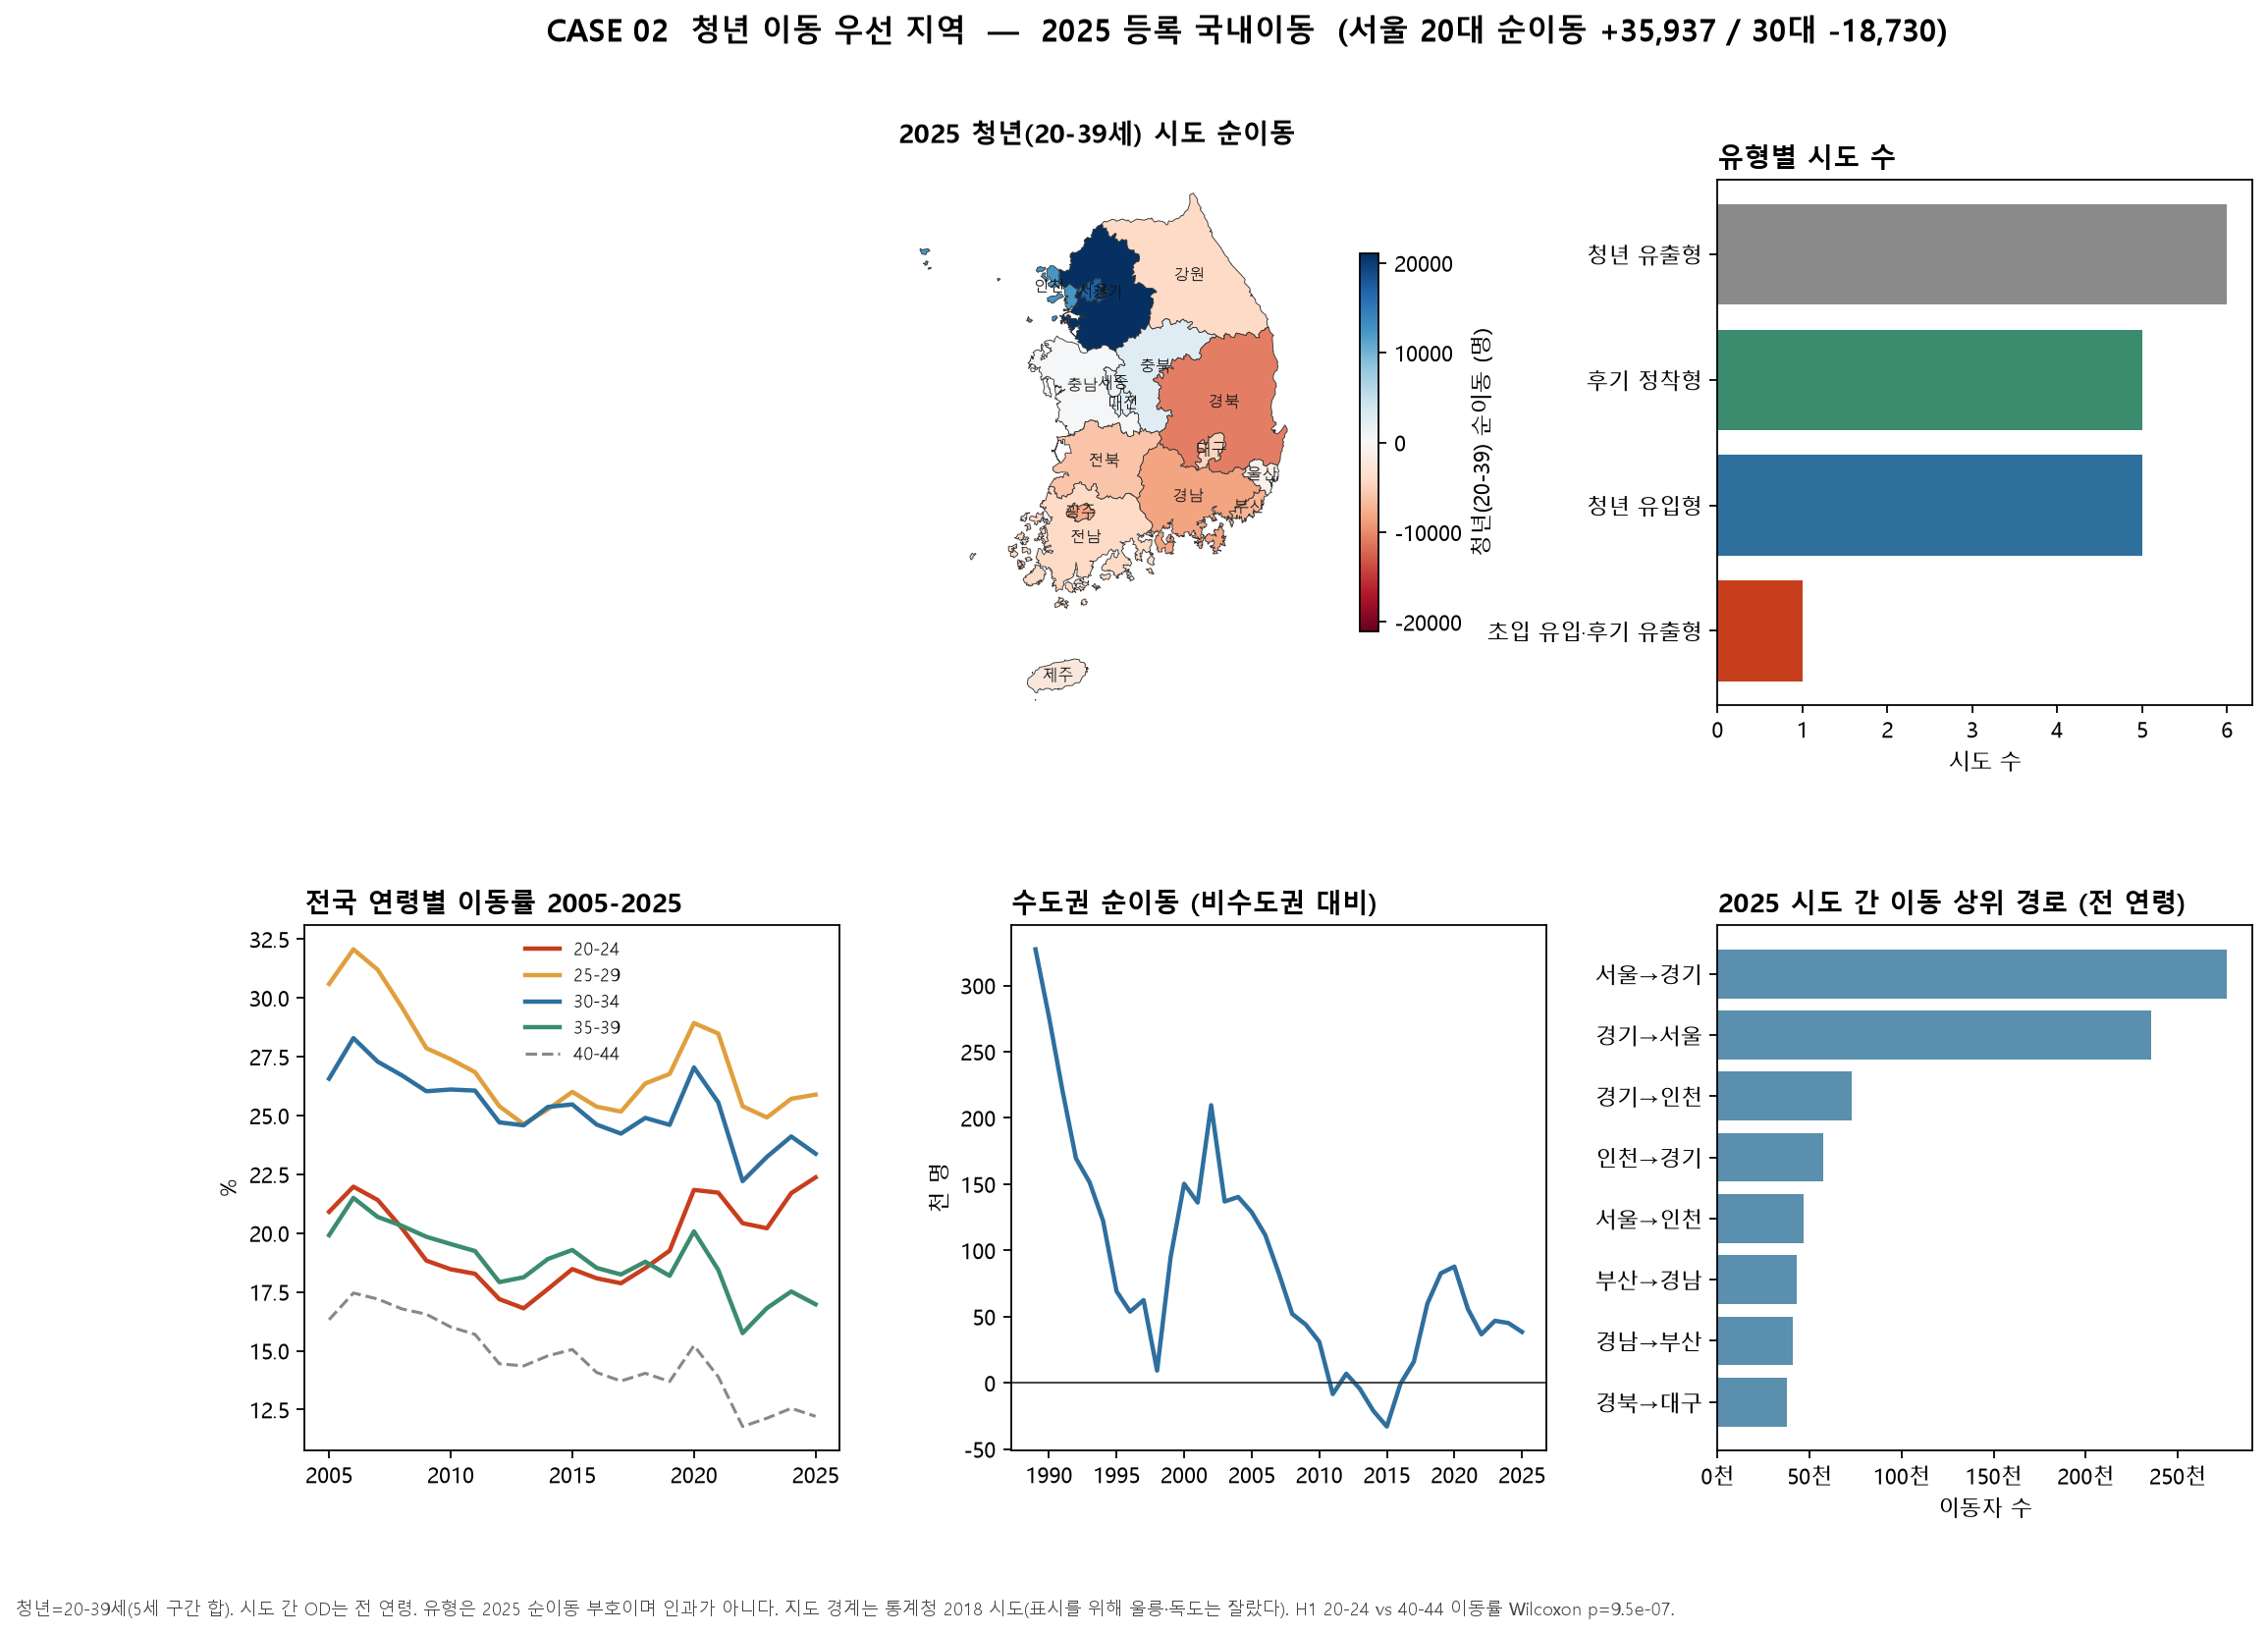

D:\golden-data-lab\golden-data-lab\cases\02_youth_migration_dynamics\evidence\dashboard\01_one_page_decision.png


In [1]:
from pathlib import Path
import sys

CASE_NAME = "02_youth_migration_dynamics"
RAW_NAME = "2025_domestic_migration_statistics.xlsx"
candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "cases" / CASE_NAME,
]
CASE_DIR = next(
    (path.resolve() for path in candidates if (path / "data" / "raw" / RAW_NAME).exists()),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(
        f"{RAW_NAME}를 찾지 못했습니다. 저장소 루트 또는 notebooks 폴더에서 실행하세요."
    )
sys.path.insert(0, str(CASE_DIR / "src"))

from constants import RAW_FILE_NAME
from data_preparation import load_and_prepare
from data_quality import run_quality_checks
from kpi_segmentation import run_kpi_segmentation
from parse_official_tables import verify_source_file
from statistical_analysis import run_statistical_analysis

RAW = CASE_DIR / "data" / "raw" / RAW_FILE_NAME
source = verify_source_file(RAW)
prepared = load_and_prepare(RAW)
tables = prepared.tables
print(source["sha256"])
print("stale sheet present:", tables.workbook["has_stale_monthly_sheet"])

from IPython.display import Image, display
from decision_dashboard import save_decision_dashboard
from kpi_segmentation import run_kpi_segmentation
from statistical_analysis import run_statistical_analysis

stats = run_statistical_analysis(tables, prepared)
kpis = run_kpi_segmentation(tables, prepared)
path = CASE_DIR / "evidence" / "dashboard" / "01_one_page_decision.png"
save_decision_dashboard(tables, prepared, stats, kpis, path)
display(Image(filename=str(path)))
print(path)


In [2]:
kpis.priority

,priority_group,sido,typology_ko,net_youth_20_39,net_20s,net_30s,net_total,is_capital
0,"Early-career inflow, later outflow",서울,초입 유입·후기 유출형,17207,35937,-18730,-26769,True
1,Youth inflow (20s and 30s),경기,청년 유입형,21053,7439,13614,32970,True
2,Youth inflow (20s and 30s),인천,청년 유입형,12472,5004,7468,32264,True
3,Youth inflow (20s and 30s),충북,청년 유입형,2543,450,2093,10789,False
4,"20s outflow, 30s inflow",충남,후기 정착형,292,-1133,1425,8266,False
5,"20s outflow, 30s inflow",울산,후기 정착형,-1112,-1154,42,-5474,False
6,"20s outflow, 30s inflow",전남,후기 정착형,-4197,-5094,897,1334,False
7,"20s outflow, 30s inflow",대구,후기 정착형,-4673,-4884,211,-4272,False
8,"20s outflow, 30s inflow",경남,후기 정착형,-8545,-9129,584,-7577,False
9,Youth net outflow,경북,청년 유출형,-10759,-8839,-1920,-9214,False


시도 간 상위 경로는 전 연령이다. 청년 순이동 막대와 같은 화면에 두더라도 연령을 섞어 읽지 않는다. 해석은 `INSIGHTS.md`다.